# 1. IMPORTAR TODAS LAS LIBRERIAS

In [274]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import legend

# 2. INICIALIZAR VARIABLES QUE DESPUES MODIFICAREMOS

In [275]:
hostnames = []
dataset=[]
df= None

# 3. Crear una funcion para generar hostnames en base a las reglas establecidas

In [276]:
def set_hostnames(number_of_hosts: int) -> None:
  os_prefix  = ['L']*40 + ['S']*30 + ['A']*20 + ['H']*10 #Linux:40% - Solaris:30% - AIX:20% - HP-UX:10%
  dev_prefix= ['P']*30 + ['T']*25 + ['S']*25 + ['D']*10 +['I']*10 #Production: 30% - Testing: 25% - Staging: 25% - Development: 10% - Integration: 10%
  country_prefix= ['IRL']*30 + ['DEU']*23 + ['ITA']*16 + ['ESP']*16 +['FRA']*9 + ['NOR']*6 #Ireland: 30% - Germany: 23% - Italy: 16% - Spain: 16% - France: 9% - Norway: 6%
  grupo_alpha=[]

  for i in range(number_of_hosts):
    host=random.choice(os_prefix)+random.choice(dev_prefix)+random.choice(country_prefix)
    grupo_alpha.append(host)
    host += str(grupo_alpha.count(host)).zfill(3)
    hostnames.append(host)


# 4. Crear una funcion para obtener el nombre del sistema operativo

In [277]:
def get_os(hostname: str) -> str:
  if(hostname.startswith('L')):
    return 'LINUX'

  elif (hostname.startswith('S')):
    return 'SOLARIS'

  elif(hostname.startswith('A')):
    return 'AIX'

  elif(hostname.startswith('H')):
    return 'HP-UX'

  else:
     return 'Unknow'



# 5. Funcion para obtener el nombre del entorno

In [278]:
def get_dev(hostname: str) -> str:
    host_dev = hostname[1]

    if host_dev.startswith('P'):
        return 'PRODUCTION'

    elif host_dev.startswith('T'):
        return 'TESTING'

    elif host_dev.startswith('S'):
        return 'STAGING'

    elif host_dev.startswith('D'):
        return 'DEVELOPMENT'

    elif host_dev.startswith('I'):
        return 'INTEGRATION'
    else:
        return 'Unknown'


# 6. Funcion para obtener el nombre del pais

In [279]:
def get_country(hostname: str) -> str:
    host_country = hostname[2:5]
    if host_country.startswith('IRL'):
        return 'IRELAND'

    elif host_country.startswith('DEU'):
        return 'GERMANY'

    elif host_country.startswith('ITA'):
        return 'ITALY'

    elif host_country.startswith('ESP'):
        return 'SPAIN'

    elif host_country.startswith('FRA'):
        return 'FRANCE'

    elif host_country.startswith('NOR'):
        return 'NORWAY'

    else:
        return 'Unknown'


# 7. Crear función pra generar el DataFrame

In [280]:
def set_dataframe(count:int) -> None:
  global df
  set_hostnames(count)

  for codigo in hostnames:
    dataset.append(
        {
            'hostname': codigo,
            'os': get_os(codigo),
            'environment': get_dev(codigo),
            'country': get_country(codigo),
            'node': int(codigo[-3:])
        }
    )



  df = pd.DataFrame(dataset)



# 8. Crear el Data Frame

In [281]:
set_dataframe(1500)
df

,hostname,os,environment,country,node
0,LPIRL001,LINUX,PRODUCTION,IRELAND,1
1,LTFRA001,LINUX,TESTING,FRANCE,1
2,STITA001,SOLARIS,TESTING,ITALY,1
3,LSIRL001,LINUX,STAGING,IRELAND,1
4,LTITA001,LINUX,TESTING,ITALY,1
...,...,...,...,...,...
1495,ATDEU012,AIX,TESTING,GERMANY,12
1496,AIDEU015,AIX,INTEGRATION,GERMANY,15
1497,HTITA010,HP-UX,TESTING,ITALY,10
1498,ASFRA008,AIX,STAGING,FRANCE,8


# 9. Guardar el Data Frame generado en un CSV

In [282]:
df.to_csv(
    'dataset_hosts.csv',
    header=True,
    index=False
    )

df_hosts=pd.read_csv('dataset_hosts.csv')
df_hosts

,hostname,os,environment,country,node
0,LPIRL001,LINUX,PRODUCTION,IRELAND,1
1,LTFRA001,LINUX,TESTING,FRANCE,1
2,STITA001,SOLARIS,TESTING,ITALY,1
3,LSIRL001,LINUX,STAGING,IRELAND,1
4,LTITA001,LINUX,TESTING,ITALY,1
...,...,...,...,...,...
1495,ATDEU012,AIX,TESTING,GERMANY,12
1496,AIDEU015,AIX,INTEGRATION,GERMANY,15
1497,HTITA010,HP-UX,TESTING,ITALY,10
1498,ASFRA008,AIX,STAGING,FRANCE,8


# 10.Generar un único gráfico, agrupando para cada país (country) los entornos


<Axes: xlabel='country'>

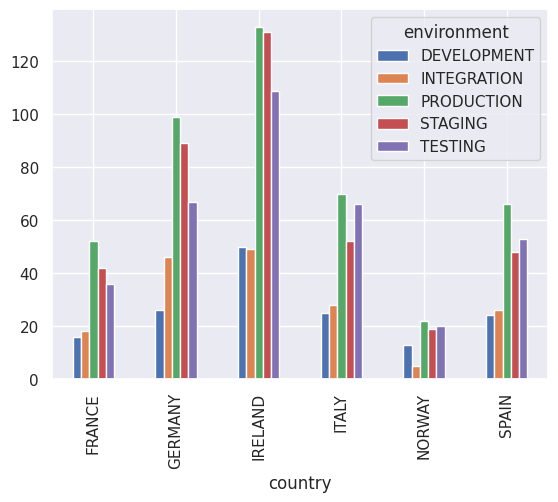

In [283]:
g=df.groupby(['country','environment']).size().unstack().plot(kind='bar')
g

# 11. GRAFICOS

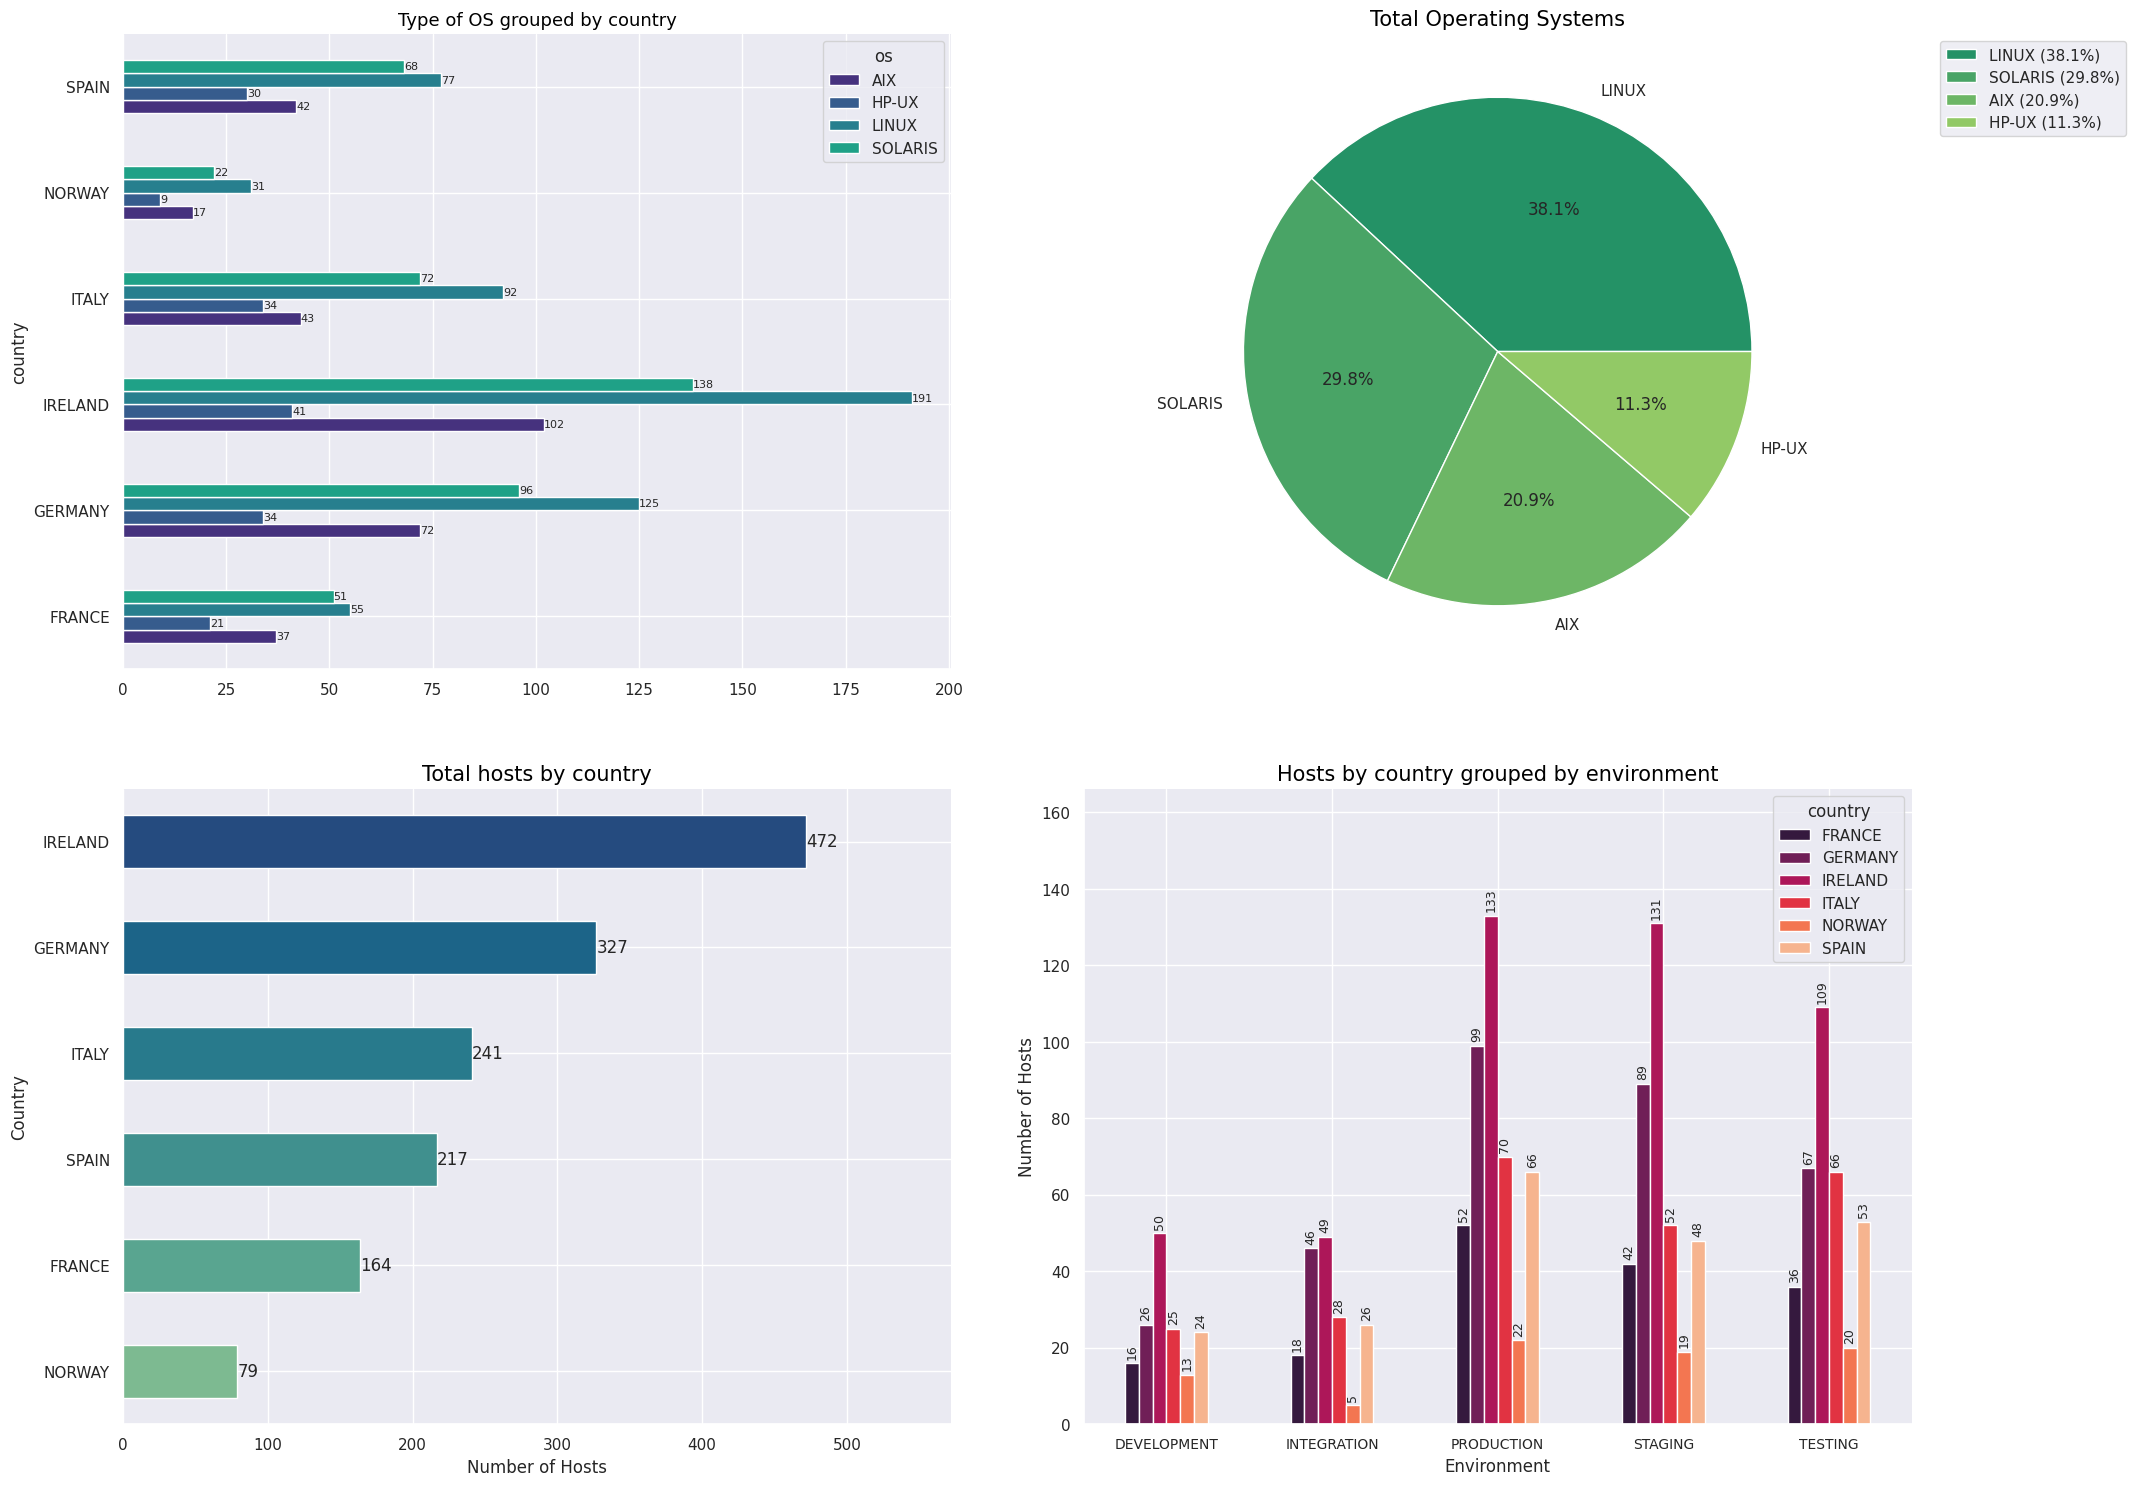

In [293]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(22, 16))


#GRAFICO 1
palette=sns.color_palette('viridis')
df.groupby(['country', 'os']).size().unstack().plot(kind='barh', ax=ax1, color=palette)

ax1.set_title('Type of OS grouped by country', color='black', fontsize=13)

for contenedor in ax1.containers:
    ax1.bar_label(contenedor,fontsize=8)




#GRAFICO 2
palette_2=sns.color_palette('summer')
ax2.set_title('Total Operating Systems', color='black', fontsize=15)

counts=df.groupby(['os']).size().sort_values(ascending=False)
total=counts.sum()

legend_labels = [f'{os} ({(v/total)*100:.1f}%)' for os, v in counts.items()]

counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%',colors=palette_2)

ax2.legend(
    labels=legend_labels,
    loc="upper right",
    bbox_to_anchor=(1.5, 1)
)

#GRAFICO 3

palette_3 = sns.color_palette('crest')

counts_country=df['country'].value_counts().sort_values(ascending=True)

counts_country.plot(kind='barh', ax=ax3, color=palette_3)

ax3.set_title('Total hosts by country', color='black', fontsize=15)
ax3.set_xlabel('Number of Hosts')
ax3.set_ylabel('Country')

for contenedor in ax3.containers:
    ax3.bar_label(contenedor,fontsize=12)

ax3.set_xlim(0, counts_country.max() + 100)

#Grafico 4
palette_4 = sns.color_palette('rocket')
g4=df.groupby(['environment','country']).size().unstack()
g4.plot(kind='bar',ax=ax4,color=palette_4)
ax4.set_ylabel('Number of Hosts')
ax4.set_xlabel('Environment')
ax4.set_title('Hosts by country grouped by environment', color='black', fontsize=15)
ax4.set_ylim(0, g4.values.max() * 1.25)

for contenedor in ax4.containers:
    ax4.bar_label(contenedor, fontsize=9, padding=3, rotation=90)

ax4.tick_params(axis='x', labelrotation=0, labelsize=10)
plt.setp(ax4.get_xticklabels(), rotation=0)

sns.despine(left=False,bottom=False)
fig.tight_layout(pad=4.0)





